Step 1: Upload your 'powerconsumption.csv' file.


Saving powerconsumption.csv to powerconsumption (1).csv

✅ powerconsumption (1).csv loaded successfully!
Columns found: ['date', 'AWND', 'PRCP', 'TMAX', 'TMIN', 'daily_consumption']

   MODEL RESULTS FOR LINKEDIN
R-Squared (Accuracy): 0.3483
Mean Absolute Error:  384.33
Mean Squared Error:   251395.14


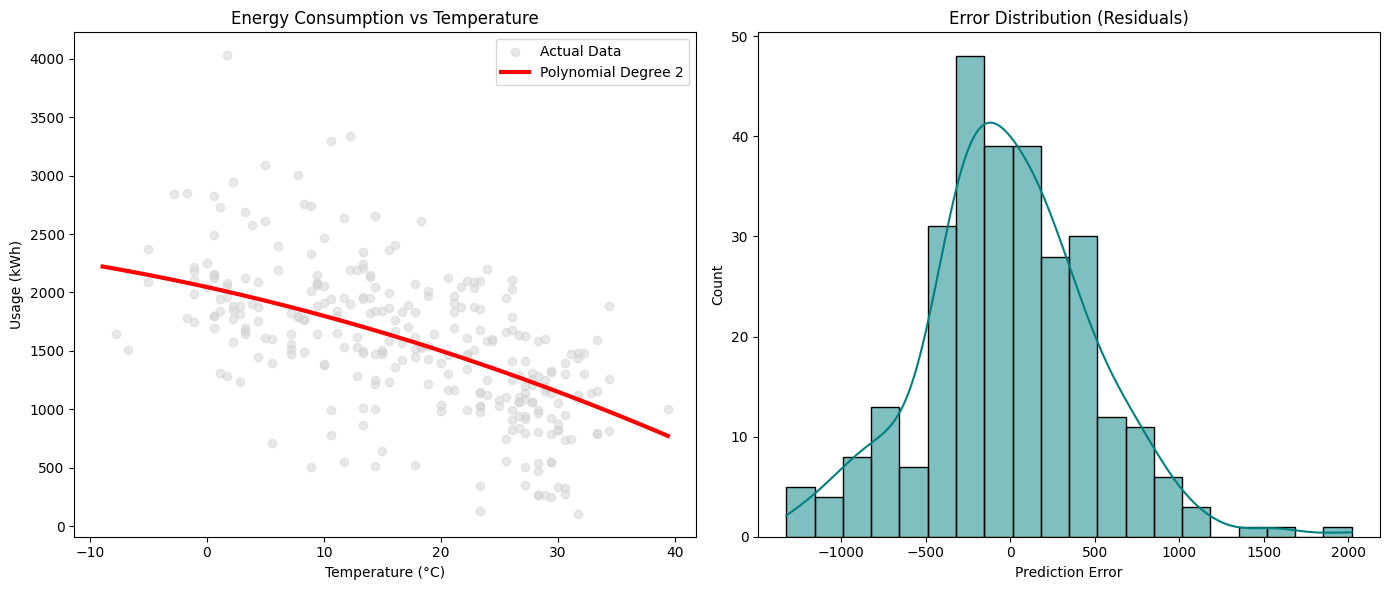


✅ Success! File 'best_energy_model.pkl' and 'energy_analysis_plot.png' are ready in the sidebar.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ==========================================
# 1. UPLOAD DATASET FROM DESKTOP
# ==========================================
print("Step 1: Upload your 'powerconsumption.csv' file.")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"\n✅ {filename} loaded successfully!")
print("Columns found:", df.columns.tolist())

# ==========================================
# 2. SELECT FEATURES & PREPROCESSING
# ==========================================
# Adjusted to match your specific CSV columns:
# We'll use TMAX as the temperature variable
X = df[['TMAX']].values
y = df['daily_consumption'].values

# Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling is highly recommended for Polynomial Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 3. POLYNOMIAL MODELING
# ==========================================
# Degree 2 captures the 'U-Curve' of energy demand
degree = 2
poly = PolynomialFeatures(degree=degree)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# Training the model
model = LinearRegression()
model.fit(X_train_poly, y_train)

# ==========================================
# 4. EVALUATION & METRICS
# ==========================================
y_pred = model.predict(X_test_poly)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("\n" + "="*30)
print("   MODEL RESULTS FOR LINKEDIN")
print("="*30)
print(f"R-Squared (Accuracy): {r2:.4f}")
print(f"Mean Absolute Error:  {mae:.2f}")
print(f"Mean Squared Error:   {mse:.2f}")
print("="*30)

# ==========================================
# 5. PROFESSIONAL VISUALIZATION
# ==========================================
plt.figure(figsize=(14, 6))

# Plot A: The Polynomial Fit
plt.subplot(1, 2, 1)
plt.scatter(X_test, y_test, color='lightgray', alpha=0.5, label='Actual Data')

# Create a smooth line for the prediction curve
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_range_poly = poly.transform(scaler.transform(X_range))
y_range_pred = model.predict(X_range_poly)

plt.plot(X_range, y_range_pred, color='red', linewidth=3, label=f'Polynomial Degree {degree}')
plt.title("Energy Consumption vs Temperature", fontsize=12)
plt.xlabel("Temperature (°C)")
plt.ylabel("Usage (kWh)")
plt.legend()

# Plot B: Residual Distribution (The 'Confusion Matrix' equivalent)
plt.subplot(1, 2, 2)
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color='teal')
plt.title("Error Distribution (Residuals)", fontsize=12)
plt.xlabel("Prediction Error")

plt.tight_layout()
plt.savefig('energy_analysis_plot.png')
plt.show()

# ==========================================
# 6. EXPORT BEST MODEL WEIGHTS
# ==========================================
joblib.dump(model, 'best_energy_model.pkl')
print("\n✅ Success! File 'best_energy_model.pkl' and 'energy_analysis_plot.png' are ready in the sidebar.")